In [1]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
from scr.qsvdd_core.data_loader import QuantumDataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Credit Card Fraud Detection

## Global Configurations & Constants

Key hyperparameters and settings shared across the full pipeline:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `dataset` | `'fraud'` | Dataset identifier used internally |
| `n_train` | `0` | Number of training anomalies (one-class: only normals) |
| `latent_dim` | `3` | Dimensionality of the quantum latent space |
| `cost_func` | `'svdd'` | Loss function — SVDD hypersphere objective |
| `learning_rate` | `0.001` | Optimizer step size for all ansatzes |

## Dataset Loading and Exploratory Data Analysis (EDA)

We use the [Kaggle Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). It contains **284,807 transactions** made by European cardholders in September 2013, with **492 fraud cases** (~0.17%).

**Feature overview:**
- `Time`: Seconds elapsed since the first transaction.
- `V1–V28`: Principal components obtained via PCA (original features are confidential).
- `Amount`: Transaction amount (not PCA-transformed).
- `Class`: Target label — `0` = legitimate, `1` = fraud.

In [3]:
print("Current directory:", os.getcwd())
print("Files in this folder:", os.listdir())

Current directory: C:\Users\jeffe\Documents\GitHub\HE-Quantum-Anomaly-Detection\notebooks
Files in this folder: ['circuit_visualization.ipynb', 'classic_occ_algorithms.ipynb', 'noise_data_visualization.ipynb', 'training_test_data.ipynb', 'training_test_data_with_pca.ipynb', 'views.ipynb']


In [4]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset loaded successfully!\n")
print("First 5 records:\n", df.head())

Dataset loaded successfully!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14126

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


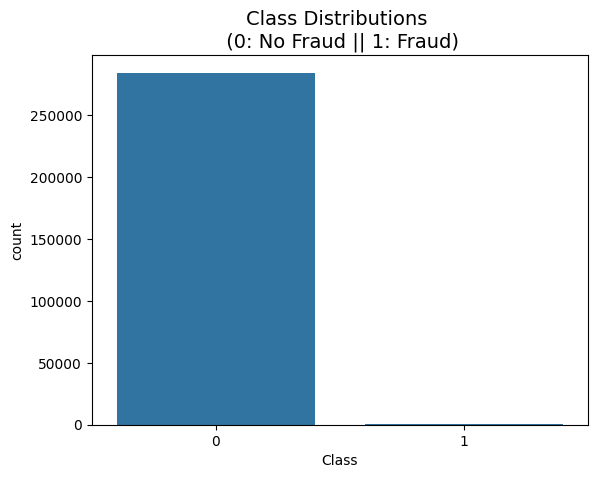

In [7]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [8]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [9]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [11]:
loader = QuantumDataLoader()

X_data, y = loader.prepare_classic_data(df)

print(f"Features for the circuit: {X_data.shape}")
print(f"Labels: {y.shape}")

Features for the circuit: (284807, 30)
Labels: (284807,)


In [12]:
"""
One-class Training (Classical):
Separation into normal and fraudulent examples.
The model will learn the representation of normality.
"""
# 1. Identify indices for each class
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# 2. Training Set (X_train contains only legitimate transactions)
# Collect 1000 normal examples for training
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train = X_data[X_train_normal_indices]
Y_train = y[X_train_normal_indices]

# 3. Test Set (Balanced: 100 normal + 100 fraud)
# Remove indices already used in training to avoid data leakage
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))

# Select 100 unseen normal samples and 100 fraud samples
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)

X_test_normal = X_data[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

X_test_abnormal = X_data[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# Create final test set with 200 examples (50% normal, 50% fraud)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

# --- Note on Deep SVDD ---
# If running classical Deep SVDD, you will need a 'center'
# in the latent space. For IF, SVM, and LOF, this is not required.
# latent_dim_classic = X_data.shape[1]
# center_train = np.tile(np.zeros(latent_dim_classic), (len(X_train), 1))

print(f"X_train shape (Normal): {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test_normal shape: {X_test_normal.shape}")
print(f"X_test_abnormal shape: {X_test_abnormal.shape}")
print(f"X_test shape (Mix): {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape (Normal): (1000, 30)
Y_train shape: (1000,)
X_test_normal shape: (100, 30)
X_test_abnormal shape: (100, 30)
X_test shape (Mix): (200, 30)
Y_test shape: (200,)


In [13]:
# Dictionary to store results for each run
results = {
    "Isolation Forest": [],
    "One-Class SVM": [],
    "LOF": []
}

n_runs = 5

for i in range(n_runs):
    # Change seed for each run to ensure different samples
    current_seed = 42 + i
    np.random.seed(current_seed)

    # 1. Split data (Train: 1000 normal / Test: 100 normal + 100 fraud)
    normal_indices = np.where(y == 0)[0]
    abnormal_indices = np.where(y == 1)[0]

    idx_train = np.random.choice(normal_indices, 1000, replace=False)
    remaining_normal = list(set(normal_indices) - set(idx_train))

    idx_test_norm = np.random.choice(remaining_normal, 100, replace=False)
    idx_test_abnorm = np.random.choice(abnormal_indices, 100, replace=False)

    X_train_run = X_data[idx_train]
    X_test_run = np.concatenate((X_data[idx_test_norm], X_data[idx_test_abnorm]), axis=0)
    y_test_run = np.concatenate((np.zeros(100), np.ones(100)), axis=0)

    # 2. Instantiate Models
    models = {
        "Isolation Forest": IsolationForest(n_estimators=100, contamination=0.01, random_state=current_seed),
        "One-Class SVM": OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'),
        "LOF": LocalOutlierFactor(n_neighbors=20, novelty=True)
    }

    # 3. Train and Evaluate
    for name, model in models.items():
        model.fit(X_train_run)

        # For AUC, we need decision scores rather than binary classes
        if name == "LOF":
            # Invert scores as lower values indicate anomalies in LOF
            y_scores = -model.decision_function(X_test_run)
        else:
            # Invert decision_function (which returns negative for anomalies)
            # so that higher scores = higher probability of fraud
            y_scores = -model.decision_function(X_test_run)

        auc = roc_auc_score(y_test_run, y_scores)
        results[name].append(auc)

# 4. Display Means and Standard Deviation in a formatted table
print(f"\n{'='*55}")
print(f"{'Classical Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")

for name, scores in results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    print(f"{name:<25} | {mean_auc:<12.4f} | {std_auc:<10.4f}")

print(f"{'='*55}\n")


Classical Algorithm       | Mean AUC     | Std AUC   
--------------------------|--------------|-----------
Isolation Forest          | 0.9615       | 0.0088    
One-Class SVM             | 0.9648       | 0.0081    
LOF                       | 0.9674       | 0.0038    



In [14]:
latent_dim = 3

class SVDD(nn.Module):
    def __init__(self, latent_dim, num_filters=3):
        super(SVDD, self).__init__()
        self.num_filters = num_filters
        self.latent_dim = latent_dim
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=self.num_filters)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=self.num_filters, out_channels=self.num_filters, kernel_size=2, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=self.num_filters)
        self.conv3 = nn.Conv1d(in_channels=self.num_filters, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(num_features=2)

        self.fc1 = nn.Linear(8, self.latent_dim)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)


train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

svdd = SVDD(latent_dim=latent_dim).to(device)

from torchsummary import summary
summary(svdd, input_size=(30,))


weight_decay = 0.001
optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=weight_decay)
loss_history = []

c = None

def initialize_center_c(dataloader, model):
    model.eval()
    with torch.no_grad():
        center = torch.zeros(model.latent_dim, device=device) # Use the global device
        for data in dataloader:
            inputs, _ = data

            inputs = inputs.unsqueeze(1).to(device)
            outputs = model(inputs)
            center += torch.sum(outputs, dim=0)

            center /= outputs.shape[0]
            break
    model.train()
    return center

def train(num_steps):
    global c
    for step in range(num_steps):
        # Get data from loader
        try:
            data = next(iter_loader)
        except (NameError, StopIteration):
            iter_loader = iter(train_dataloader)
            data = next(iter_loader)

        inputs, _ = data

        inputs = inputs.unsqueeze(1).to(device)

        optimizer.zero_grad()

        if c is None:
            c = initialize_center_c(train_dataloader, svdd)

        outputs = svdd(inputs)

        loss = torch.mean(torch.sum((outputs - c) ** 2, dim=1))

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if step % 10 == 0:
            print('Step: {} | Loss: {:.6f}'.format(step, loss.item()))


train(num_steps=500)

Layer (type:depth-idx)                   Param #
├─Conv1d: 1-1                            9
├─BatchNorm1d: 1-2                       6
├─MaxPool1d: 1-3                         --
├─Conv1d: 1-4                            21
├─BatchNorm1d: 1-5                       6
├─Conv1d: 1-6                            14
├─BatchNorm1d: 1-7                       4
├─Linear: 1-8                            27
Total params: 87
Trainable params: 87
Non-trainable params: 0
Step: 0 | Loss: 0.631168
Step: 10 | Loss: 0.732874
Step: 20 | Loss: 0.323435
Step: 30 | Loss: 0.705022
Step: 40 | Loss: 0.311910
Step: 50 | Loss: 0.283286
Step: 60 | Loss: 0.216946
Step: 70 | Loss: 0.149648
Step: 80 | Loss: 0.201709
Step: 90 | Loss: 0.172028
Step: 100 | Loss: 0.161761
Step: 110 | Loss: 0.101819
Step: 120 | Loss: 0.153777
Step: 130 | Loss: 0.113621
Step: 140 | Loss: 0.155348
Step: 150 | Loss: 0.156824
Step: 160 | Loss: 0.070340
Step: 170 | Loss: 0.063889
Step: 180 | Loss: 0.103354
Step: 190 | Loss: 0.080902
Step: 200 | 

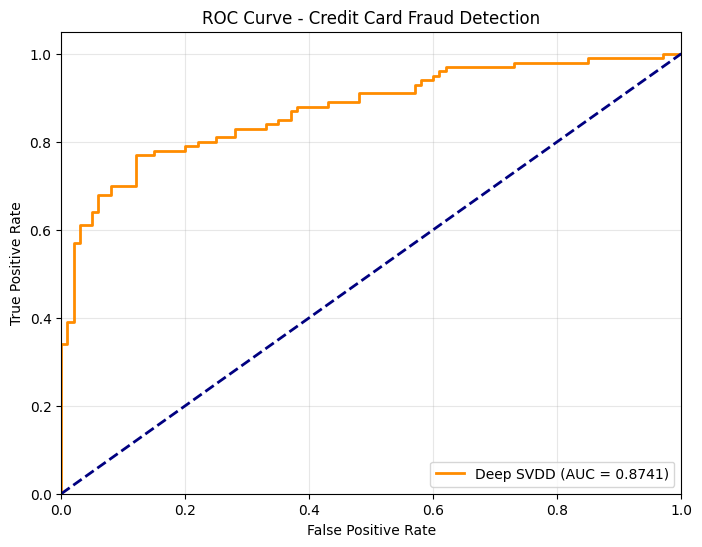

Final Deep SVDD AUC: 0.8741


In [15]:
def evaluate_and_plot_auc(model, dataloader, center):
    model.eval()
    distances = []
    labels = []

    with torch.no_grad():
        for data in dataloader:
            inputs, target = data

            inputs = inputs.unsqueeze(1).to(device)

            outputs = model(inputs)

            dist = torch.sum((outputs - center) ** 2, dim=1)

            distances.append(dist.cpu().item())
            labels.append(target.item())


    auc_score = roc_auc_score(labels, distances)
    fpr, tpr, _ = roc_curve(labels, distances)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Deep SVDD (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Credit Card Fraud Detection')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return auc_score

# Run evaluation
dsvdd_auc = evaluate_and_plot_auc(svdd, test_dataloader, c)
print(f"Final Deep SVDD AUC: {dsvdd_auc:.4f}")

In [16]:
from sklearn.metrics import roc_auc_score

def evaluate_dsvdd(model, dataloader, center):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for data in dataloader:
            inputs, target = data
            inputs = inputs.unsqueeze(1).to(device)

            outputs = model(inputs)
            # Score is the distance to the center 'c'
            dist = torch.sum((outputs - center) ** 2, dim=1)

            scores.append(dist.cpu().item())
            labels.append(target.item())

    auc = roc_auc_score(labels, scores)
    return auc

# Calculate final AUC for DSVDD
dsvdd_auc = evaluate_dsvdd(svdd, test_dataloader, c)
print(f"\nDeep SVDD AUC on Breast Cancer: {dsvdd_auc:.4f}")


Deep SVDD AUC on Breast Cancer: 0.8741


# Breast Cancer anomaly Detection

In [17]:
print("="*60)
print("Loading and processing the Breast Cancer dataset...")
print("="*60)

# 1. Fetch the dataset
breast_cancer = fetch_ucirepo(id=17)
X_bc_raw = breast_cancer.data.features
y_bc_raw = breast_cancer.data.targets

Loading and processing the Breast Cancer dataset...


In [18]:
print(breast_cancer.data.features.head())

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

In [19]:
X_bc_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavity2         

In [20]:
y_bc_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Diagnosis  569 non-null    str  
dtypes: str(1)
memory usage: 4.6 KB


In [21]:
# 2. Binarization for Anomaly Detection
# 'M' (Malignant) = 1 (Anomaly), 'B' (Benign) = 0 (Normal)
y_bc = y_bc_raw.iloc[:, 0].apply(lambda x: 1 if x == 'M' else 0).values

# 3. Use the DataLoader for classical scaling (StandardScaler)
loader = QuantumDataLoader()
# We pass the raw features and the binarized targets
# Note: Since prepare_classic_data expects a DataFrame with a "Class" column,
# we temporarily combine them or adjust the method.
import pandas as pd
df_bc = pd.DataFrame(X_bc_raw)
df_bc['Class'] = y_bc

X_data, y = loader.prepare_classic_data(df_bc)

# 4. Identify indices for each class
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# 5. Training Set (One-Class: 200 normal samples)
X_train_normal_indices = np.random.choice(normal_indices, 200, replace=False)
X_train = X_data[X_train_normal_indices]
Y_train = y[X_train_normal_indices]

# 6. Test Set (Balanced: 50 normal + 50 anomalies)
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))

X_test_normal_indices = np.random.choice(remaining_normal_indices, 50, replace=False)
X_test_abnormal_indices = np.random.choice(abnormal_indices, 50, replace=False)

X_test_normal = X_data[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

X_test_abnormal = X_data[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# Final test set (Mix: 100 samples)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

print(f"X_train shape (Normal): {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape (Mix): {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape (Normal): (200, 30)
Y_train shape: (200,)
X_test shape (Mix): (100, 30)
Y_test shape: (100,)


In [22]:
# Dictionary to store results for each run
results = {
    "Isolation Forest": [],
    "One-Class SVM": [],
    "LOF": []
}

n_runs = 5

for i in range(n_runs):
    # Change seed for each run to ensure different samples
    current_seed = 42 + i
    np.random.seed(current_seed)

    # 1. Identify indices for each class
    normal_indices = np.where(y == 0)[0]
    abnormal_indices = np.where(y == 1)[0]

    # 2. Split data (Adjusted for Breast Cancer size: Train 200 / Test 50+50)
    # Using 200 normal samples for training
    idx_train = np.random.choice(normal_indices, 200, replace=False)
    remaining_normal = list(set(normal_indices) - set(idx_train))

    # Using 50 normal + 50 abnormal samples for testing
    idx_test_norm = np.random.choice(remaining_normal, 50, replace=False)
    idx_test_abnorm = np.random.choice(abnormal_indices, 50, replace=False)

    X_train_run = X_data[idx_train]
    X_test_run = np.concatenate((X_data[idx_test_norm], X_data[idx_test_abnorm]), axis=0)
    y_test_run = np.concatenate((np.zeros(50), np.ones(50)), axis=0)

    # 3. Instantiate Models
    models = {
        "Isolation Forest": IsolationForest(n_estimators=100, contamination=0.01, random_state=current_seed),
        "One-Class SVM": OneClassSVM(kernel='rbf', nu=0.1, gamma='scale'),
        "LOF": LocalOutlierFactor(n_neighbors=20, novelty=True)
    }

    # 4. Train and Evaluate
    for name, model in models.items():
        model.fit(X_train_run)

        # For AUC, we need decision scores rather than binary classes
        if name == "LOF":
            # Invert scores as lower values indicate anomalies in LOF
            y_scores = -model.decision_function(X_test_run)
        else:
            # Invert decision_function (which returns negative for anomalies)
            y_scores = -model.decision_function(X_test_run)

        auc = roc_auc_score(y_test_run, y_scores)
        results[name].append(auc)

# 5. Display Means and Standard Deviation in a formatted table
print(f"\n{'='*55}")
print(f"{'Classical Algorithm':<25} | {'Mean AUC':<12} | {'Std AUC':<10}")
print(f"{'-'*25}-|-{'-'*12}-|-{'-'*10}")

for name, scores in results.items():
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    print(f"{name:<25} | {mean_auc:<12.4f} | {std_auc:<10.4f}")

print(f"{'='*55}\n")


Classical Algorithm       | Mean AUC     | Std AUC   
--------------------------|--------------|-----------
Isolation Forest          | 0.9690       | 0.0140    
One-Class SVM             | 0.9550       | 0.0168    
LOF                       | 0.9366       | 0.0265    



In [23]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Convert to PyTorch Tensors
# Note: Breast Cancer usually has 30 features
x_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

# Create Datasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# DataLoaders
# Batch size 16 is fine for 200 samples
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1)

# Configuration
latent_dim = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Model
svdd = SVDD(latent_dim=latent_dim).to(device)

# Hyperparameters
weight_decay = 0.001
optimizer = torch.optim.Adam(svdd.parameters(), lr=0.001, weight_decay=weight_decay)

# Global variables for training
c = None
loss_history = []

# Run training
# Since the dataset is small, 500 steps is plenty (around 40 epochs)
train(num_steps=500)

Step: 0 | Loss: 0.691617
Step: 10 | Loss: 0.597467
Step: 20 | Loss: 0.325547
Step: 30 | Loss: 0.222218
Step: 40 | Loss: 0.166938
Step: 50 | Loss: 0.112210
Step: 60 | Loss: 0.228407
Step: 70 | Loss: 0.131962
Step: 80 | Loss: 0.133533
Step: 90 | Loss: 0.170566
Step: 100 | Loss: 0.081814
Step: 110 | Loss: 0.094598
Step: 120 | Loss: 0.066474
Step: 130 | Loss: 0.090083
Step: 140 | Loss: 0.132335
Step: 150 | Loss: 0.042237
Step: 160 | Loss: 0.073098
Step: 170 | Loss: 0.076712
Step: 180 | Loss: 0.065837
Step: 190 | Loss: 0.078500
Step: 200 | Loss: 0.030846
Step: 210 | Loss: 0.045692
Step: 220 | Loss: 0.053672
Step: 230 | Loss: 0.029198
Step: 240 | Loss: 0.032596
Step: 250 | Loss: 0.037884
Step: 260 | Loss: 0.029835
Step: 270 | Loss: 0.038014
Step: 280 | Loss: 0.029182
Step: 290 | Loss: 0.030238
Step: 300 | Loss: 0.029634
Step: 310 | Loss: 0.021785
Step: 320 | Loss: 0.016994
Step: 330 | Loss: 0.031979
Step: 340 | Loss: 0.022461
Step: 350 | Loss: 0.058406
Step: 360 | Loss: 0.011242
Step: 370 | 

In [24]:
from sklearn.metrics import roc_auc_score

def evaluate_dsvdd(model, dataloader, center):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for data in dataloader:
            inputs, target = data
            inputs = inputs.unsqueeze(1).to(device)

            outputs = model(inputs)
            # Score is the distance to the center 'c'
            dist = torch.sum((outputs - center) ** 2, dim=1)

            scores.append(dist.cpu().item())
            labels.append(target.item())

    auc = roc_auc_score(labels, scores)
    return auc

# Calculate final AUC for DSVDD
dsvdd_auc = evaluate_dsvdd(svdd, test_dataloader, c)
print(f"\nDeep SVDD AUC on Breast Cancer: {dsvdd_auc:.4f}")


Deep SVDD AUC on Breast Cancer: 0.6892
